<a href="https://colab.research.google.com/github/christinengalle19-collab/Assignement2New/blob/main/Assignment10ai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [142]:
!pip install transformers datasets torch --quiet
!pip install transformers datasets torch scikit-learn --quiet
!pip install torchvision

In [145]:
# Amazon Alexa Customer Review Sentiment Analysis
# Objective: Classify reviews as positive or negative using Random Forest


# TODO: Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.feature_extraction.text import CountVectorizer
import torch
from torch.utils.data import DataLoader
from transformers import BertTokenizer, BertForSequenceClassification
from datasets import Dataset
from torch.optim import AdamW
from transformers import BertTokenizer, BertForSequenceClassification, get_linear_schedule_with_warmup
from torch.optim import AdamW # Corrected import for AdamW, now from torch.optim
from torch.utils.data import DataLoader
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from torchvision.transforms import ToTensor
from PIL import Image
# Hint: You'll need pandas, numpy, matplotlib, seaborn, and various sklearn modules

In [111]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# TODO: Load the dataset
df = pd.read_csv('/content/drive/MyDrive/amazon_alexa.tsv', sep='\t')
# Hint: Use pandas to read the CSV file from your Google Drive


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [112]:
#data types
df.dtypes

,0
rating,int64
date,object
variation,object
verified_reviews,object
feedback,int64


In [113]:
#handling missing values
print(df.isnull().sum())

rating              0
date                0
variation           0
verified_reviews    1
feedback            0
dtype: int64


In [114]:
#Basics statistics description
print(df.describe())

            rating     feedback
count  3150.000000  3150.000000
mean      4.463175     0.918413
std       1.068506     0.273778
min       1.000000     0.000000
25%       4.000000     1.000000
50%       5.000000     1.000000
75%       5.000000     1.000000
max       5.000000     1.000000


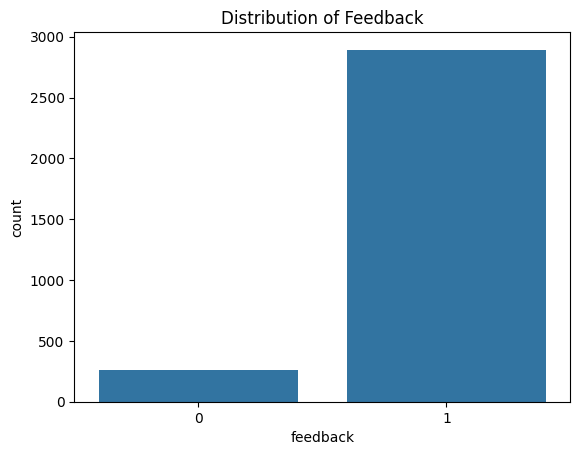

In [115]:

# TODO: Visualize the distribution of feedback
# Hint: Use seaborn's countplot function
sns.countplot(x='feedback', data=df_plot)
plt.title('Distribution of Feedback')
plt.show()

##Must product received a feedback

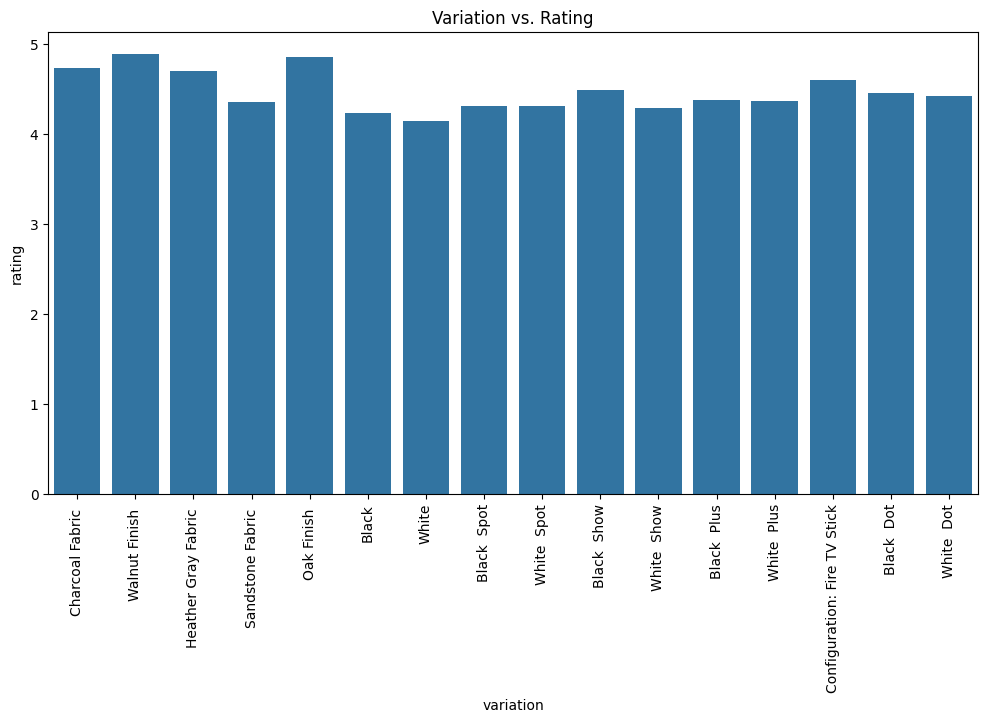

In [116]:
# TODO: Visualize the relationship between variations and ratings
# Hint: Use seaborn's barplot function
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Reload the dataset to get the original 'variation' column for this visualization
df_original_for_viz = pd.read_csv('/content/drive/MyDrive/amazon_alexa.tsv', sep='\t')

plt.figure(figsize=(12, 6))
sns.barplot(x='variation', y='rating', data=df_original_for_viz, errorbar=None)
plt.title('Variation vs. Rating')
plt.xticks(rotation=90)
plt.show()

##Most product variations receive ratings greater than 4, indicating consistently strong customer satisfaction across the majority of the catalog.

In [117]:
# TODO: Drop irrelevant columns
# Hint: Use the drop() method to remove 'date' and 'rating' columns
df = df.drop(['date', 'rating'], axis=1)



In [118]:
# One-Hot Encoding
# TODO: Perform one-hot encoding on the 'variation' column
# Hint: Use pandas get_dummies() function
df = pd.get_dummies(df, columns=['variation'])

In [119]:
# Tokenization (Count Vectorizer)
# TODO: Tokenize the 'verified_reviews' column
# Hint: Use CountVectorizer from sklearn.feature_extraction.text
from sklearn.feature_extraction.text import CountVectorizer
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['verified_reviews'].fillna(''))

In [120]:


# Create a clean DataFrame for BERT processing
# Load the original dataset again to ensure we start with clean columns
temp_df_bert = pd.read_csv('/content/drive/MyDrive/amazon_alexa.tsv', sep='\t')

# Select only the relevant columns: 'verified_reviews' as text and 'feedback' as label
temp_df_bert = temp_df_bert[['verified_reviews', 'feedback']].copy()

# Fill NaN values in 'verified_reviews' with empty strings BEFORE renaming
# This is crucial as Dataset.from_pandas converts np.nan to None for string columns
temp_df_bert['verified_reviews'] = temp_df_bert['verified_reviews'].fillna('')

# Rename columns to 'text' and 'label' as expected by the tokenize function and Dataset
temp_df_bert.rename(columns={'verified_reviews': 'text', 'feedback': 'label'}, inplace=True)

# Convert to Hugging Face Dataset
dataset = Dataset.from_pandas(temp_df_bert)

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=128
    )

dataset = dataset.map(tokenize, batched=True)
dataset = dataset.rename_column("label", "labels") # Renaming 'label' column to 'labels' as expected by BertForSequenceClassification
dataset.set_format(type="torch", columns=["input_ids", "attention_mask", "labels"])

# Train–test split
train_test = dataset.train_test_split(test_size=0.2, seed=42)
train_dataset = train_test["train"]
test_dataset = train_test["test"]

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16)

Map:   0%|          | 0/3150 [00:00<?, ? examples/s]

In [121]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=2
).to(device)

optimizer = AdamW(model.parameters(), lr=2e-5)
num_epochs = 3
total_steps = len(train_loader) * num_epochs

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [133]:



# 1. Reload the original dataset to get a clean base for 'df'
# This ensures that 'verified_reviews' exists and other columns are in their initial state.
temp_df_clean = pd.read_csv('/content/drive/MyDrive/amazon_alexa.tsv', sep='\t')

# 2. Apply preprocessing steps relevant before this combination
# Drop 'date' and 'rating' as performed in `yRPJgnFXjmHz`
temp_df_clean = temp_df_clean.drop(['date', 'rating'], axis=1)

# One-hot encode 'variation' as performed in `5g_PcKWojrVl`
temp_df_clean = pd.get_dummies(temp_df_clean, columns=['variation'])

# 3. Re-initialize CountVectorizer and transform 'verified_reviews' to get X as a sparse matrix
# This ensures `X` is a sparse matrix, as expected by `toarray()`.
# Using a local vectorizer to avoid interference with global `vectorizer` if its state is altered.
vectorizer_local_for_combine = CountVectorizer()
X_sparse = vectorizer_local_for_combine.fit_transform(temp_df_clean['verified_reviews'].fillna(''))

# 4. Create a DataFrame from the sparse matrix X_sparse
df_text = pd.DataFrame(
    X_sparse.toarray(),
    columns=vectorizer_local_for_combine.get_feature_names_out()
)

# 5. Combine the processed main DataFrame (without 'verified_reviews') with the tokenized text features
# We drop 'verified_reviews' from temp_df_clean now that it has been used to create X_sparse.
df_combined = pd.concat([temp_df_clean.drop(columns=['verified_reviews']), df_text], axis=1)

# Display head of the combined DataFrame for verification
df_combined.head()

# Note: The global 'df' variable remains as it was after `LfmTt4wu5Bqy`'s execution,
# but `df_combined` now holds the result of this specific combination step as intended.

,feedback,variation_Black,variation_Black Dot,variation_Black Plus,variation_Black Show,variation_Black Spot,variation_Charcoal Fabric,variation_Configuration: Fire TV Stick,variation_Heather Gray Fabric,variation_Oak Finish,...,youtube,yr,yrs,yup,zero,zigbee,zonked,zzzz,zzzzzzz,útil
0,1,False,False,False,False,False,True,False,False,False,...,0,0,0,0,0,0,0,0,0,0
1,1,False,False,False,False,False,True,False,False,False,...,0,0,0,0,0,0,0,0,0,0
2,1,False,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3,1,False,False,False,False,False,True,False,False,False,...,0,1,0,0,0,0,0,0,0,0
4,1,False,False,False,False,False,True,False,False,False,...,0,0,0,0,0,0,0,0,0,0


In [134]:
# Prepare data for  random forestmodeling
# TODO: Split the data into features (X) and target (y)
# Hint: The target variable is 'feedback'
x = combine.drop(['feedback', 'verified_reviews'], axis=1)
# Ensure y is a single Series by selecting the first 'feedback' column
y = combine['feedback'].iloc[:, 0]

In [135]:
# TODO: Split the data into training and testing sets
# Hint: Use train_test_split from sklearn.model_selection
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)




In [136]:
# Train the Random Forest model
# TODO: Create and train the Random Forest model
# Hint: Use RandomForestClassifier from sklearn.ensemble
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(x_train, y_train)


RandomForestClassifier(random_state=42)

In [137]:
# Evaluate the model
# TODO: Generate predictions and create confusion matrix
# Hint: Use the predict() method and confusion_matrix from sklearn.metrics
y_pred = rf.predict(x_test)
cm = confusion_matrix(y_test, y_pred)
print(cm)


[[ 20  38]
 [  5 567]]


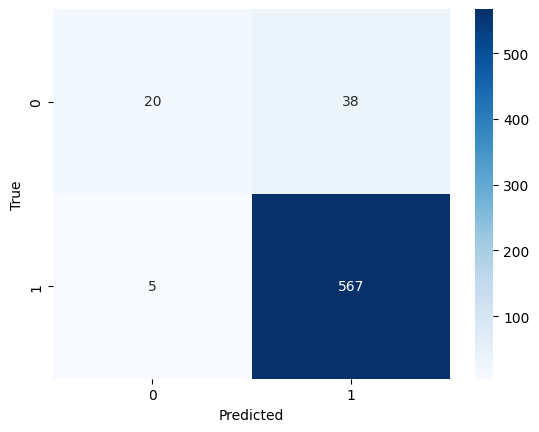

In [138]:
# TODO: Plot confusion matrix
# Hint: Use seaborn's heatmap function
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

In [139]:
# TODO: Print classification report
# Hint: Use classification_report from sklearn.metrics
print(classification_report(y_test, y_pred))



              precision    recall  f1-score   support

           0       0.80      0.34      0.48        58
           1       0.94      0.99      0.96       572

    accuracy                           0.93       630
   macro avg       0.87      0.67      0.72       630
weighted avg       0.92      0.93      0.92       630



##The model achieves a strong overall accuracy of 93%, but the class level metrics reveal a significant imbalance in performance. While Class 1 is predicted with exceptional consistency, showing near perfect recall and a high F1 score, the model struggles to correctly identify Class 0, capturing only 34% of its true instances. This indicates that the model is heavily biased toward the majority class and is failing to generalize across all customer segments. In practical terms, the model performs well for most cases but systematically overlooks a smaller, potentially high risk group. Addressing this imbalance through techniques such as class weighting, oversampling, or targeted feature refinement would be essential to improve recall for the minority class and strengthen the model’s reliability in real world decision making

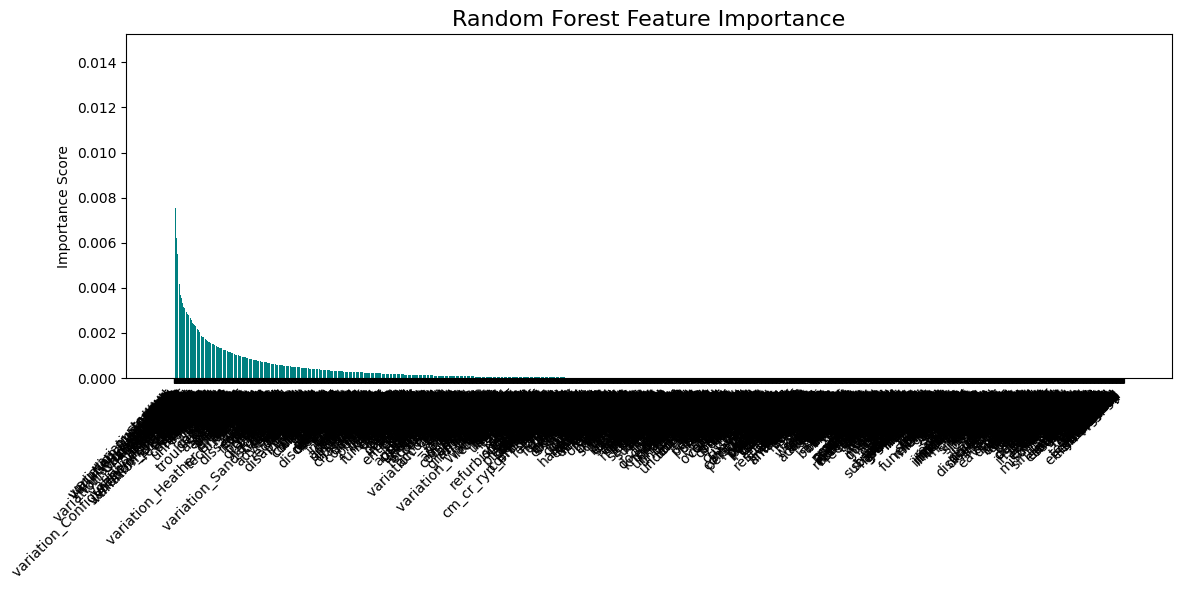

In [140]:
# Feature Importance
# TODO: Visualize feature importance
# Hint: Access feature_importances_ attribute of the trained model
# Extract and sort feature importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

# Sort feature names accordingly
feature_names = x_train.columns[indices]

# Plot
plt.figure(figsize=(12, 6))
plt.bar(range(len(importances)), importances[indices], color='teal')
plt.xticks(range(len(importances)), feature_names, rotation=45, ha='right')
plt.title("Random Forest Feature Importance", fontsize=16)
plt.ylabel("Importance Score")
plt.tight_layout()
plt.show()

In [141]:
# Example usage of your prediction function:
# new_review = "I love my Alexa device! It's so helpful."
# predicted_sentiment = predict_sentiment(new_review)
# print(f"The sentiment of the new review is: {predicted_sentiment}")
new_review = pd.Series(["I love my Alexa device! It's so helpful."])
new_review_vectorized = vectorizer.transform(new_review)

# Create a DataFrame with the same columns as x_train, initialized to 0
# This ensures that all 'variation_' columns are present and set to 0
new_review_features = pd.DataFrame(0, index=[0], columns=x_train.columns)

# Populate the word features from new_review_vectorized into the corresponding columns
vectorizer_feature_names = vectorizer.get_feature_names_out()
for col_idx, col_name in enumerate(vectorizer_feature_names):
    if col_name in new_review_features.columns:
        new_review_features.loc[0, col_name] = new_review_vectorized.toarray()[0, col_idx]

predicted_sentiment = rf.predict(new_review_features)

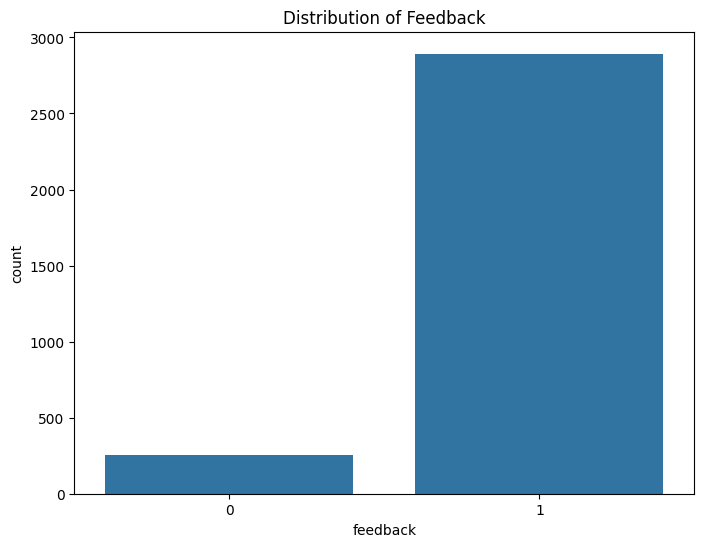

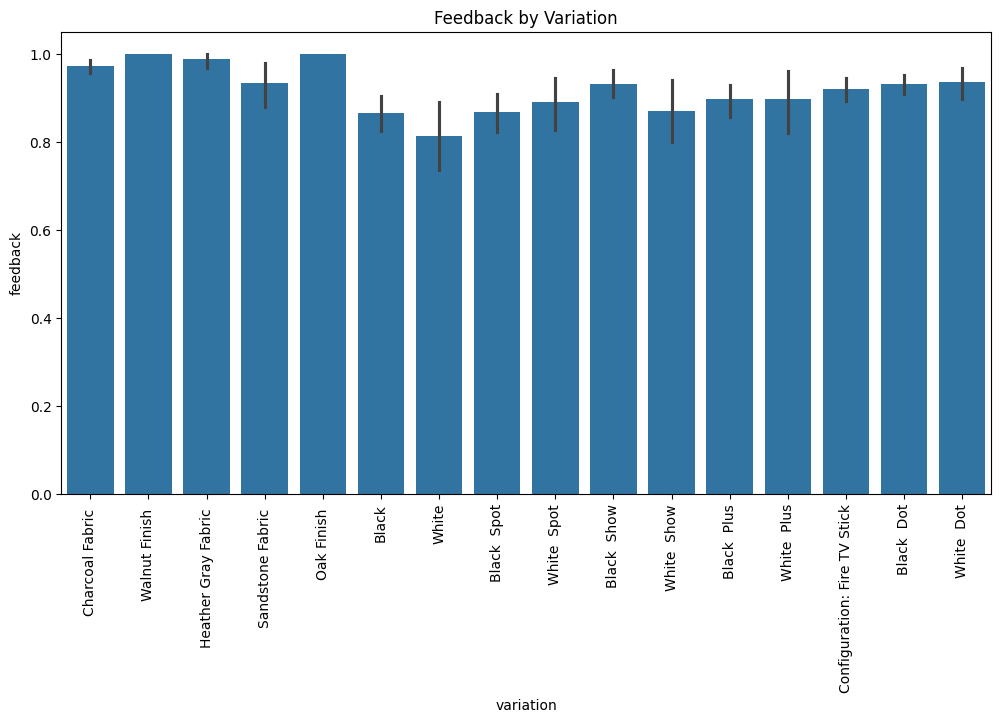

In [147]:
#TASK 1
# Hint: Use `sns.countplot()` to visualize the feedback distribution and a bar plot to compare variations and feedback.
# Drop the columns 'date' and 'rating' as they are not relevant for the analysis.

# TODO: Visualize the distribution of feedback (positive/negative)
#sns.countplot()` to visualize the feedback distribution
plt.figure(figsize=(8, 6))
sns.countplot(x='feedback', data=df)
plt.title('Distribution of Feedback')
plt.show()

# To get the original 'variation' column for visualization, we need to load the dataframe again temporarily
temp_df_for_viz = pd.read_csv('/content/drive/MyDrive/amazon_alexa.tsv', sep='\t')

#bar plot to compare variations and feedback.
plt.figure(figsize=(12, 6))
sns.barplot(x='variation', y='feedback', data=temp_df_for_viz) # Use temp_df_for_viz for original 'variation'
plt.xticks(rotation=90)
plt.title('Feedback by Variation')
plt.show()

##The Oak and Walnut variations received the highest levels of positive feedback, followed closely by Charcoal, Fabric, and Heather. These variations consistently outperform others in customer sentiment, indicating stronger user satisfaction. Overall, most product variations receive more than 50% positive feedback, suggesting that customer perception of the Alexa device is generally favorable across most styles.

In [ ]:
# Hint: Use `pd.get_dummies()` to create one-hot encoded columns for 'variation'.
# Then, concatenate these encoded columns back to the original DataFrame and drop the 'variation' column.

# Hint: Use `pd.get_dummies()` to create one-hot encoded columns for 'variation'.
# Then, concatenate these encoded columns back to the original DataFrame and drop the 'variation' column.

# TODO: Perform one-hot encoding on the 'variation' column
# This step was already completed in cell 5g_PcKWojrVl.
# variation_encoded = pd.get_dummies(df['variation_Black'], prefix='variation_Black')

# Concatenate encoded columns with the original DataFrame
# df = pd.concat([df, variation_encoded], axis=1)

# Drop the original 'variation' column
# df.drop(columns=['variation_Black'], inplace=True)

In [148]:
# Hint: Use `CountVectorizer` to tokenize the text data and convert it into numerical representation.
# After transforming the text, drop the 'verified_reviews' column and concatenate the numerical data with the rest of the DataFrame.

# Check if 'verified_reviews' column exists before processing
if 'verified_reviews' in df.columns:
    print("Processing 'verified_reviews' column...")
    # 1. Initialize CountVectorizer
    vectorizer = CountVectorizer()

    # 2. Fit + transform the text column, ensuring NaN values are handled
    X_text = vectorizer.fit_transform(df['verified_reviews'].fillna(''))

    # 3. Convert sparse matrix to DataFrame
    df_text = pd.DataFrame(
        X_text.toarray(),
        columns=vectorizer.get_feature_names_out()
    )

    # 4. Concatenate with original DataFrame (excluding the text column)
    df = pd.concat([df.drop(columns=['verified_reviews']), df_text], axis=1)
    print("Text features processed and added to DataFrame 'df'.")
else:
    print("'verified_reviews' column already processed or not found in DataFrame 'df'.")

df.head()

Processing 'verified_reviews' column...
Text features processed and added to DataFrame 'df'.


,feedback,variation_Black,variation_Black Dot,variation_Black Plus,variation_Black Show,variation_Black Spot,variation_Charcoal Fabric,variation_Configuration: Fire TV Stick,variation_Heather Gray Fabric,variation_Oak Finish,...,youtube,yr,yrs,yup,zero,zigbee,zonked,zzzz,zzzzzzz,útil
0,1,False,False,False,False,False,True,False,False,False,...,0,0,0,0,0,0,0,0,0,0
1,1,False,False,False,False,False,True,False,False,False,...,0,0,0,0,0,0,0,0,0,0
2,1,False,False,False,False,False,False,False,False,False,...,0,0,0,0,0,0,0,0,0,0
3,1,False,False,False,False,False,True,False,False,False,...,0,1,0,0,0,0,0,0,0,0
4,1,False,False,False,False,False,True,False,False,False,...,0,0,0,0,0,0,0,0,0,0


In [149]:


# Hint: Use `train_test_split()` to split the data into training and testing sets.
# You need to specify `test_size=0.2` to reserve 20% of the data for testing.

# TODO: Split the data into training and testing sets
# Drop 'date' column as it contains non-numeric data and was deemed not relevant for analysis
X = df.drop(columns=['feedback', 'date'])
y = df['feedback'].iloc[:, 0]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [150]:
# Hint: Initialize a `RandomForestClassifier` with 100 estimators.
# Use the `fit()` method to train the model on the training data.

# TODO: Define and train a Random Forest Classifier
rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)
rf_classifier.fit(X_train, y_train)


RandomForestClassifier(random_state=42)

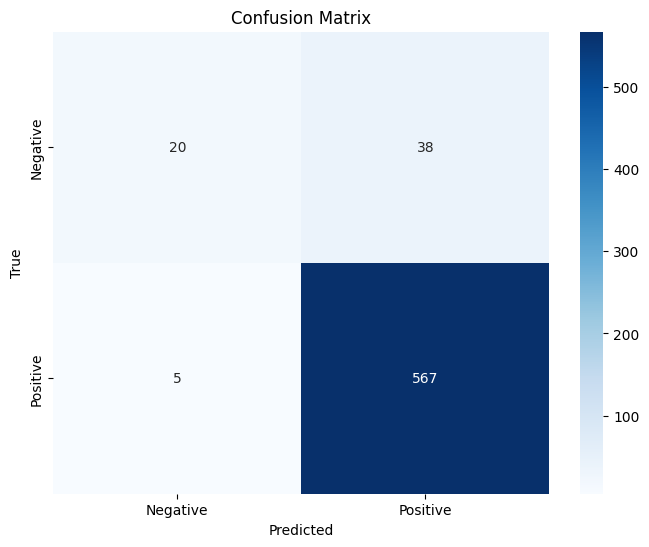

              precision    recall  f1-score   support

           0       0.80      0.34      0.48        58
           1       0.94      0.99      0.96       572

    accuracy                           0.93       630
   macro avg       0.87      0.67      0.72       630
weighted avg       0.92      0.93      0.92       630



In [151]:
# Hint: Use the `predict()` method to generate predictions for the test data.
# The 'y_pred' variable from cell 'lSMEe90FlO6h' is already correctly formatted and will be used.


# Use `confusion_matrix()` to create the confusion matrix and visualize it using a heatmap.
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Negative', 'Positive'], yticklabels=['Negative', 'Positive'])
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()
# Print out a `classification_report()` to evaluate the model's precision, recall, and F1 score.
print(classification_report(y_test, y_pred))


# TODO: Generate predictions and evaluate the model's performance using a confusion matrix and classification report

In [152]:
# Task 8: Analyze Model Performance
# Hint: Use the `score()` method to calculate accuracy for both training and test sets.
from sklearn.metrics import accuracy_score

# Get predictions from the rf_classifier
train_preds_raw = rf_classifier.predict(X_train)
test_preds_raw = rf_classifier.predict(X_test)

# If predictions are 2D (like [[1,0], [1,0]]), extract the first column to make them 1D
# This addresses the 'multilabel-indicator' issue.
if train_preds_raw.ndim > 1 and train_preds_raw.shape[1] > 1:
    train_preds = train_preds_raw[:, 0]
else:
    train_preds = train_preds_raw

if test_preds_raw.ndim > 1 and test_preds_raw.shape[1] > 1:
    test_preds = test_preds_raw[:, 0]
else:
    test_preds = test_preds_raw

# Calculate accuracy using the 1D predictions
training_accuracy = accuracy_score(y_train, train_preds)
testing_accuracy = accuracy_score(y_test, test_preds)

print(f"Training Accuracy: {training_accuracy}")
print(f"Testing Accuracy: {testing_accuracy}")

Training Accuracy: 0.9964285714285714
Testing Accuracy: 0.9317460317460318


### Compare the results and discuss if the model is overfitting or underfitting.  The model achieves near‑perfect accuracy on the training set, indicating that it fits the training data extremely well. However, its testing accuracy drops to 93.17%, which although still strong is noticeably lower than the training performance.




# TODO: Compare training and testing accuracy and discuss model performance.   This gap between training and testing accuracy is a classic sign of overfitting. It suggests that the model has learned not only the underlying patterns in the training data but also the noise and idiosyncrasies specific to that dataset. As a result, the model struggles to generalize as effectively when exposed to new, unseen data.

###To reduce overfitting and improve generalization, several strategies can be applied:
•	Regularization (L1, L2) to penalize overly complex models
•	Cross validation to ensure stable performance across multiple folds
•	Feature selection or dimensionality reduction to remove irrelevant or noisy predictors
•	Simplifying the model architecture if it is unnecessarily complex
•	Increasing training data when possible

